In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [4]:
#Unidades canónicas


In [5]:
sistema=[
    dict(m=1, r=[0,0,0], v=[0,0,0]),
    dict(m=1, r=[1,0,0], v=[0,1,0]),
]

In [6]:
ts=np.linspace(0,10,1000)
solucion=pc.ncuerpos_solucion(sistema, ts)

In [7]:
pc.ncuerpos_solucion?

Signature: pc.ncuerpos_solucion(sistema, ts)
Docstring:
Resuelve el problema N-cuerpos y calcula constantes.

Parameters
----------
sistema : list[dict]
    Lista de particulas con `m`, `r`, `v`. Cada particula es un
    diccionario con:

    - `m`: masa (o parametro gravitacional)
    - `r`: posicion inicial como iterable de 3 componentes
    - `v`: velocidad inicial como iterable de 3 componentes
ts : numpy.ndarray
    Tiempos de integracion.

    Returns
    -------
    tuple
            `(rs, vs, rps, vps, constantes)` donde:

            - `rs`, `vs`: arreglos con forma `(N, Nt, 3)` para posiciones y
                velocidades absolutas.
            - `rps`, `vps`: arreglos con forma `(N, Nt, 3)` para posiciones y
                velocidades relativas al centro de masa.
            - `constantes`: diccionario con constantes de movimiento y series
                asociadas (`M`, `RCM`, `PCM`, `L`, `K`, `U`, `E`).

Examples
--------
>>> sistema = [
...     dict(m=1.0, r=[-0.5, 0.0,

In [8]:
ts=np.linspace(0,10,1000)
rs,vs, rps,vps, constantes=pc.ncuerpos_solucion(sistema, ts)

In [9]:
rs.shape # (numero de cuerpos, numero de pasos, componentes del vector de posición)


(2, 1000, 3)

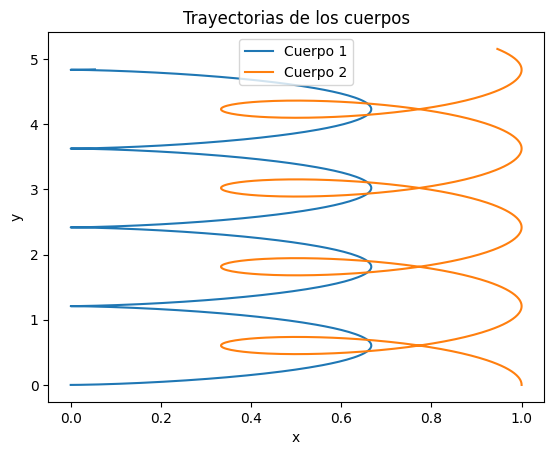

In [10]:
plt.plot(rs[0,:,0], rs[0,:,1], label='Cuerpo 1')
plt.plot(rs[1,:,0], rs[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.show()

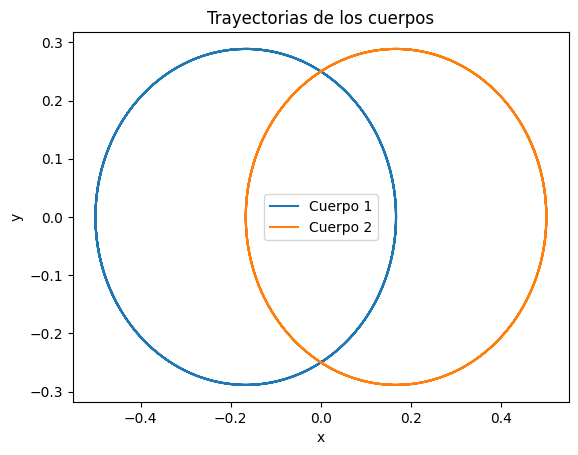

In [11]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.show()

##Cuadraturas
#momentum lineal


In [12]:
#momentum lineal total
suma= 0
for i in range(2):
    suma+= sistema[i]['m']*vs[i,0,:]
suma

array([0., 1., 0.])

##momentum angular total

In [13]:
##momentum angular total
suma= 0
for i in range(2):
    suma+= sistema[i]['m']*np.cross(rs[i,12,:], vs[i,12,:])
suma

array([0.        , 0.        , 0.99999999])

In [15]:
sistema[0]['m']*vs[0] + sistema[1]['m']*vs[1]

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(1000, 3))

In [ ]:
suma = np.sum([sistema[i]['m']*vs[i,0,:] for i in range(2)], axis=0)
suma